# 5. Phase covariance

**Note:**
- The numbers $a_1$, $a_2$ come from adjusting the data to the function $\text{Airy}_1(x)$ at two points: $(0, \text{Airy}_1(0))$ and $(0.5, \text{Airy}_1(0.5))$. 
- That must be done for each time instant, therefore $a_1(t)$ and $a_2(t)$.
- For columnar noise the data should not collapse to the $\text{Airy}_1$ function, only crossing it at the enforced points $0,0.5$. Instead it should match Larkin's one (this fact was surprising since the PDF is that of KPZ, as is $\text{Airy}_1$).
- For Larkin's function, there is no closed form solution (or at least, there is no "nicely looking" one). Instead, as with $\text{Airy}_1$, it's better to have tables of values.
- The same ideas (computing $a_1, a_2$ adjusting two points) can be used for Larkin's function, but: in this case there should be no time dependence. Also, there is a formula () 

In [1]:
import numpy as np
import pandas as pd
import os

from surface_functions import compute_phase_covariance

In [2]:
z_dict = {"TimeDep": {"EW": 2, "KPZ": 3/2}, "Columnar": {"EW": 2, "KPZ": 1.36}}
alpha_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.07}}
alpha_s_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.4}}  # anomalous scaling, only for columnar noise
alpha_loc_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 1, "KPZ": 0.96}} # anomalous scaling, only for columnar noise
beta_dict = {"TimeDep": {"EW": alpha_dict["TimeDep"]["EW"]/z_dict["TimeDep"]["EW"], "KPZ": alpha_dict["TimeDep"]["KPZ"]/z_dict["TimeDep"]["KPZ"]}, 
             "Columnar": {"EW": alpha_dict["Columnar"]["EW"]/z_dict["Columnar"]["EW"], "KPZ": alpha_dict["Columnar"]["KPZ"]/z_dict["Columnar"]["KPZ"]}}
delta_to_label = {"0": "EW", "atan5": "KPZ"}

## Dataframe computations

In [3]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"Output{typenoise}/Solutions_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        hprodh_average_list = []  # used to compute per-sim \overline{h(x,t)h(x+r,t)}
        h_average_list = []  # used to compute per-sim height \overline{h(x,t)}

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            hprodh_average, h_average = compute_phase_covariance(phases)

            hprodh_average_list.append(hprodh_average)
            h_average_list.append(h_average)

        # Avoid chained-assignment issues
        df = df.copy()
        df["hprodh_average"] = hprodh_average_list
        df["h_average"] = h_average_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE PHASE-COVARIANCE PER (K, L, T) ##
        # group by K, L, T and compute mean phase-covariance for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):
            hprodh_average_arrays = [np.asarray(r, dtype=float) for r in group["hprodh_average"]]
            h_average_arrays = [np.asarray(r, dtype=float) for r in group["h_average"]]

            # Term 1: < overline{φ(x, t) φ(x + r, t)} >
            term1 = np.mean(np.stack(hprodh_average_arrays, axis=0), axis=0)

            # Term 2: ( < overline{φ}(x, t) > )^2
            # Note: h_average_arrays has shape (M, Nt), so we mean over axis 0 to get (Nt,)
            term2 = np.mean(np.stack(h_average_arrays, axis=0), axis=0)**2

            # We need to broadcast term2 (Nt,) to match term1 (Nt, N)
            # Since term2 varies only with time, we subtract it from every 'r' column
            mean_phasecovariance = term1 - term2[:, np.newaxis]

            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "mean_phasecovariance": mean_phasecovariance,
                }
            )

        print("Seeds (index):", df.index.tolist())
        # print("Number of simulations:", M)
        print("Columns:", df.columns.tolist())

## TimeDep – Delta 0


KeyboardInterrupt: 

In [ ]:
# === add this after the loops ===
avg_df_path = "AverageSims.pkl"
avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "mean_phasecovariance"] = new_avg["mean_phasecovariance"]

avg_df.to_pickle(avg_df_path)

In [ ]:
avg_df

,typenoise,delta,deltaname,K,L,t,M,T,mean_roughness,mean_roughness2,mean_heightheight,mean_structurefactor,mean_phasecovariance,mean_varphis
avg_id,,,,,,,,,,,,,,
TimeDep_delta0_L500_K0.01_T20000_M500,TimeDep,0.000000,0,0.01,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.09932794776024303, 0.12445710235930987...","[0.0, 0.09937158963203278, 0.12451669747551469...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[-0.0027809741224855927, -9.775243609554396e-..."
TimeDep_delta0_L125_K1.0_T20000_M1000,TimeDep,0.000000,0,1.00,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",1000,20000,"[0.0, 0.06206535180620217, 0.06962088956407118...","[0.0, 0.06224447417192954, 0.06987538331690908...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[-0.006357272579978845, -0.002615458599064435..."
TimeDep_delta0_L250_K1.0_T20000_M500,TimeDep,0.000000,0,1.00,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.06185445817599045, 0.0696865309816036,...","[0.0, 0.061951592706644056, 0.0698286189854493...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.00622799567986121, 0.008318125032599795, 0..."
TimeDep_delta0_L500_K1.0_T20000_M500,TimeDep,0.000000,0,1.00,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.062281209851627814, 0.0703404523305143...","[0.0, 0.062330873676472595, 0.0704074790636151...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[-0.010824811381579355, -0.006220338756365368..."
TimeDep_delta0_L1000_K1.0_T2000_M1000,TimeDep,0.000000,0,1.00,1000,"[0.0, 1.000005000025, 1.6000080000400003, 2.56...",1000,2000,"[0.0, 0.06227872506489045, 0.07036343464658922...","[0.0, 0.06230232642291112, 0.07039760622553232...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[-0.008872702054725191, -0.011689164770830124..."
TimeDep_delta0_L1000_K1.0_T20000_M443,TimeDep,0.000000,0,1.00,1000,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",443,20000,"[0.0, 0.0625063640864414, 0.07058771172934142,...","[0.0, 0.06253163982824679, 0.07061894474218933...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0032432035605534197, 0.010503133732229096,..."
TimeDep_deltaatan5_L500_K0.01_T20000_M500,TimeDep,1.373401,atan5,0.01,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.10014740577543957, 0.1261770083222738,...","[0.0, 0.10019634453950993, 0.12623155432190383...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.03896850411797321, -0.0095273650259768, 0...."
TimeDep_deltaatan5_L125_K1.0_T20000_M1000,TimeDep,1.373401,atan5,1.00,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",1000,20000,"[0.0, 0.08497581574082771, 0.10016716020392952...","[0.0, 0.085169740061077, 0.10039858844247401, ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.008234362739468367, 0.011605615294569702, ..."
TimeDep_deltaatan5_L250_K1.0_T20000_M500,TimeDep,1.373401,atan5,1.00,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.08525314007445625, 0.10040309251048023...","[0.0, 0.08534060165610576, 0.10051558946041181...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0

In [ ]:
avg_df.loc["TimeDep_delta0_L500_K1.0_T20000_M500", "mean_phasecovariance"]

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [3.90835786e-03, 1.90669166e-03, 8.05425128e-04, ...,
        2.99939647e-04, 8.05425128e-04, 1.90669166e-03],
       [4.99070048e-03, 2.85746320e-03, 1.50755107e-03, ...,
        7.28566012e-04, 1.50755107e-03, 2.85746320e-03],
       ...,
       [3.24824976e-01, 3.22303375e-01, 3.19822630e-01, ...,
        3.17348578e-01, 3.19822630e-01, 3.22303375e-01],
       [4.42706683e-01, 4.40183000e-01, 4.37667167e-01, ...,
        4.35158013e-01, 4.37667167e-01, 4.40183000e-01],
       [5.73770400e-01, 5.71250436e-01, 5.68762340e-01, ...,
        5.66290862e-01, 5.68762340e-01, 5.71250436e-01]], shape=(23, 500))

## Inspection of the computed quantities

In [5]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science","no-latex"])

%load_ext autoreload
%autoreload 2

from plotting_helpers_evolution import plot_phasecovariance_evolution
from plotting_helpers_collapse import plot_phasecovariance_collapse

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
avg_df_path = "AverageSims.pkl"
avg_df = pd.read_pickle(avg_df_path)

L = 1000
T = 20000
Ks = [1, 40]

In [7]:
markerdict = {500: "o", 250: "x", 125: "^", 1000: "s"}

In [8]:
# Adjustment to the crossover time: t_x = tx * L**z (BY HAND for Ks=[1,40])
tx = {"TimeDep": {"EW": 1/30, "KPZ": 1/4}, "Columnar": {"EW": 1/800, "KPZ": 1/20}}

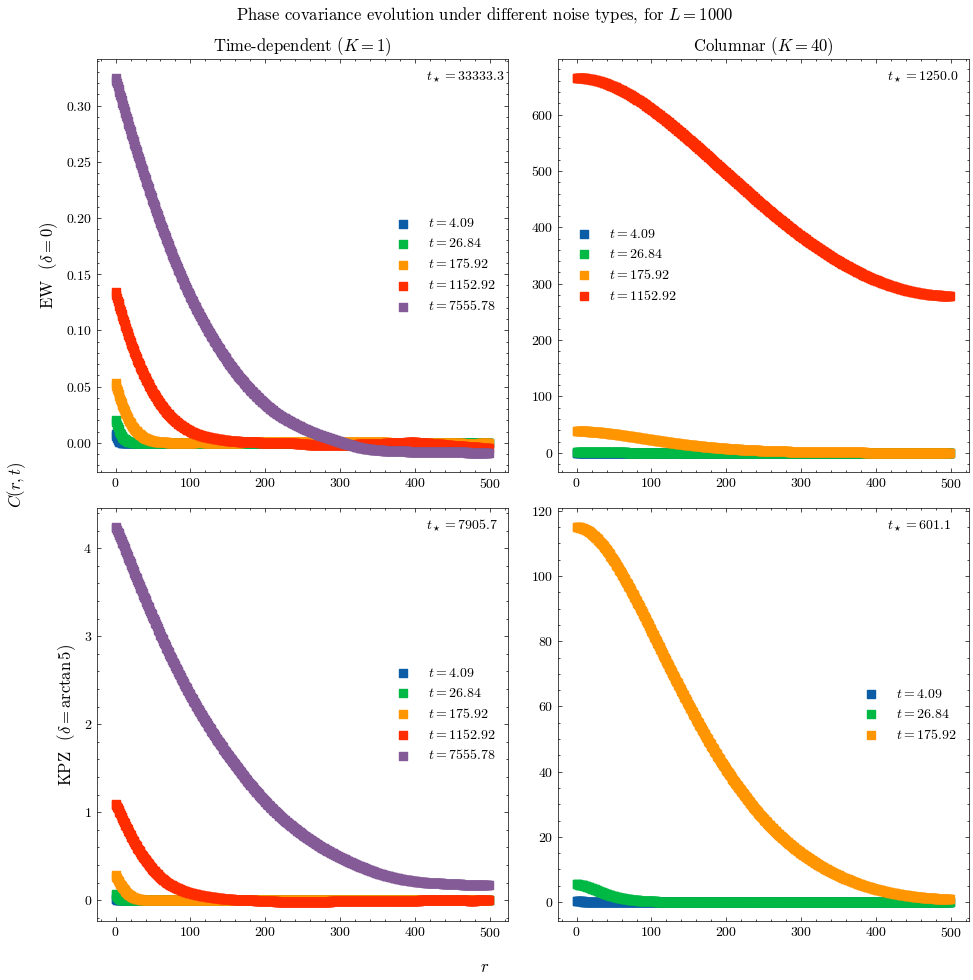

In [9]:
plot_phasecovariance_evolution(avg_df, L, T, tx, Ks=[1,40])

### Family-Vicsek collapse of the phase covariance

We need constants $a_1$, $a_2$, which are fit assuming the functional form.

In [10]:
with open("airy_1_values.txt", 'r') as f:
    Airy_1 = {float(line.split(" ")[0]): float(line.split(" ")[1]) for line in f.readlines()}

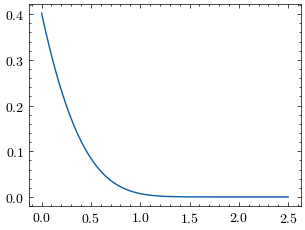

In [11]:
plt.plot(list(Airy_1.keys()), list(Airy_1.values()))

In [12]:
(0, Airy_1[0]), (0.5, Airy_1[0.5])

((0, 0.401945258645), (0.5, 0.084419174))

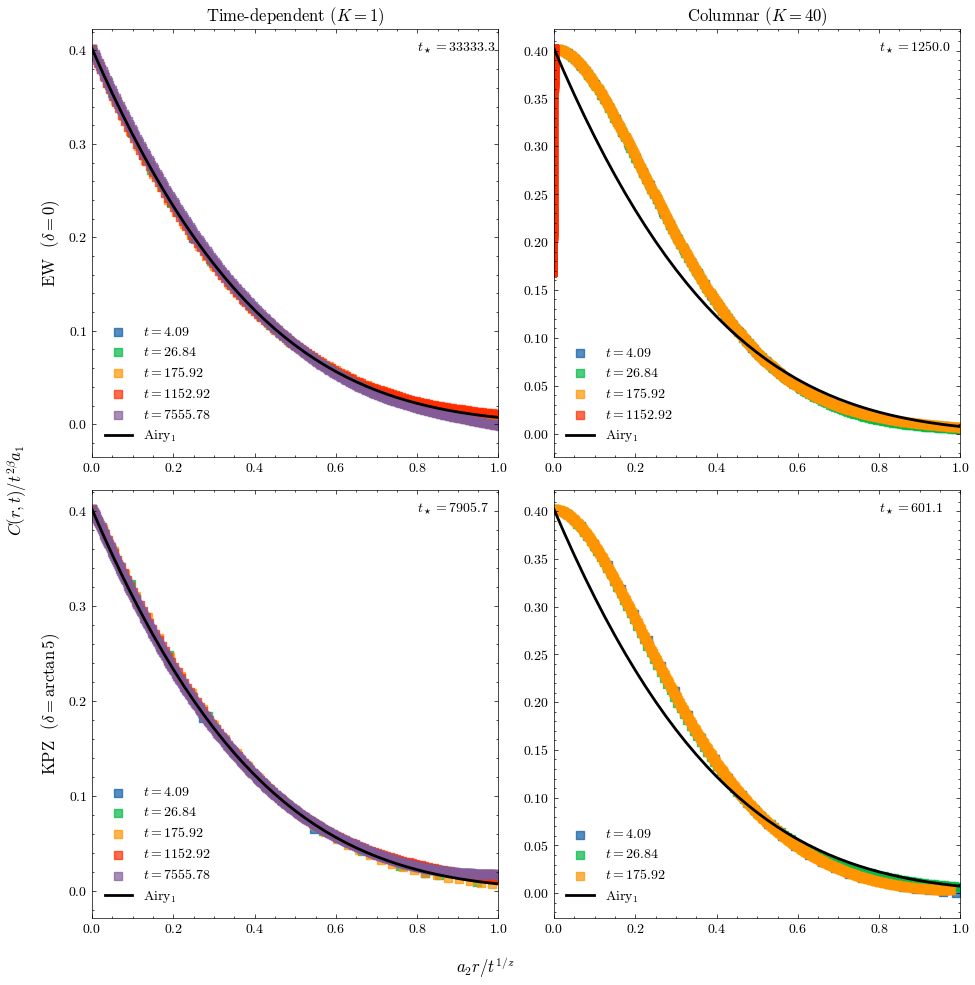

In [13]:
a_1_dict, a_2_dict = plot_phasecovariance_collapse(avg_df, L, T, tx, Ks=[1,40])

In [15]:
a_1_dict, a_2_dict

({'TimeDep': {'0': [np.float64(0.009954249413864108),
    np.float64(0.009927773858342792),
    np.float64(0.009954585114117778),
    np.float64(0.009800115749220267),
    np.float64(0.009292402933723156)],
   'atan5': [np.float64(0.018382131201394144),
    np.float64(0.018876158298008358),
    np.float64(0.022337698303775178),
    np.float64(0.024802405919991312),
    np.float64(0.027399205138715278)]},
  'Columnar': {'0': [np.float64(0.04083828618057752),
    np.float64(0.04079269077245042),
    np.float64(0.041159376867788644),
    np.float64(0.04226995817929216)],
   'atan5': [np.float64(0.07979204120417359),
    np.float64(0.07594241361436174),
    np.float64(0.08386905324463259)]}},
 {'TimeDep': {'0': [np.float64(0.2518809629394974),
    np.float64(0.25233767305701443),
    np.float64(0.24901735815242942),
    np.float64(0.25282492345397933),
    np.float64(0.2817737938499057)],
   'atan5': [np.float64(0.6975990272186753),
    np.float64(0.8497808416490494),
    np.float64(0.8586